# 1. Analyse Exploratoire des Données (EDA) et Nettoyage

Puisque nous sommes dans un cadre d'apprentissage, ce notebook est très détaillé. Nous allons passer par toutes les étapes nécessaires pour comprendre, nettoyer et préparer nos données avant de les utiliser pour des modèles d'apprentissage automatique (Machine Learning).

## Objectifs de ce Notebook :
1. **Charger les données** et jeter un premier coup d'œil.
2. **Nettoyer les données** (gestion des valeurs manquantes cachées, suppression des colonnes inutiles).
3. **Analyse Univariée et Bivariée** (visualisation des variables par rapport à la cible `Churn`).
4. **Préparation (Feature Engineering)** pour les étapes suivantes (Clustering et Classification).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Chargement et Aperçu des Données

In [11]:
df = pd.read_csv('../data/raw/wa-fn-usec-telco-customer-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Obtenir des informations sur le type des colonnes et les valeurs non nulles
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Observation importante :**
Bien que `df.info()` indique 7043 valeurs non nulles partout, la colonne `TotalCharges` est de type `object` (chaîne de caractères). Cela signifie qu'elle contient des valeurs qui ne sont pas des nombres, ce qui est une anomalie pour une colonne censée représenter un montant total.

## 2. Nettoyage des Données

In [13]:
# Vérifions pourquoi TotalCharges est un object
# Nous allons convertir la colonne en numérique, et forcer les erreurs à devenir 'NaN'
TotalCharges_num = pd.to_numeric(df['TotalCharges'], errors='coerce')
lignes_problematiques = df[TotalCharges_num.isna()]

print(f"Nombre de lignes avec TotalCharges vide : {len(lignes_problematiques)}")
lignes_problematiques[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Nombre de lignes avec TotalCharges vide : 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Explication détaillée :**
Nous pouvons voir que ces clients ont un `tenure` (ancienneté) de 0. Ce sont donc de tout nouveaux clients qui n'ont pas encore reçu leur première facture. Par conséquent, leur `TotalCharges` est un espace vide `' '`.

**Correction :**
Nous allons imputer (remplacer) ces valeurs par `0` et convertir la colonne en type numérique `float`.

In [14]:
# Remplacer les espaces par 0 et convertir en float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', '0'))

# Suppression de 'customerID' car c'est un identifiant unique sans valeur prédictive
df.drop('customerID', axis=1, inplace=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Super ! Maintenant toutes nos variables numériques (`tenure`, `MonthlyCharges`, `TotalCharges`) sont bien de types numériques (`int` ou `float`), et les autres sont catégorielles (`object`).

## 3. Analyse Exploratoire des Données (EDA)
L'objectif de l'EDA est de comprendre comment chaque variable interagit avec notre variable cible `Churn`.

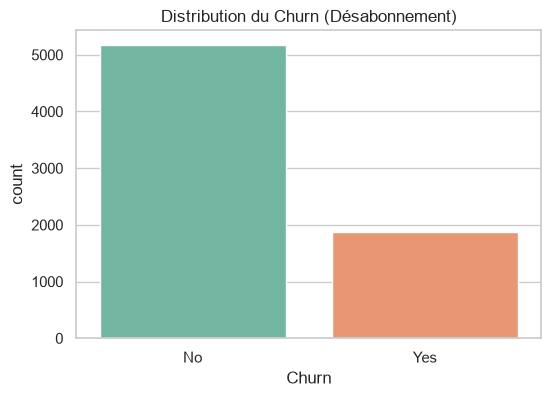

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [15]:
# Distribution de la variable cible (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution du Churn (Désabonnement)')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

**Observation :**
Les classes sont **déséquilibrées**. Environ 73.5% des clients ne se sont pas désabonnés (No) contre 26.5% qui l'ont fait (Yes). Nous devrons prendre cela en compte lors de la modélisation (en utilisant SMOTE ou des poids de classes).

### 3.1 Variables Numériques vs Churn

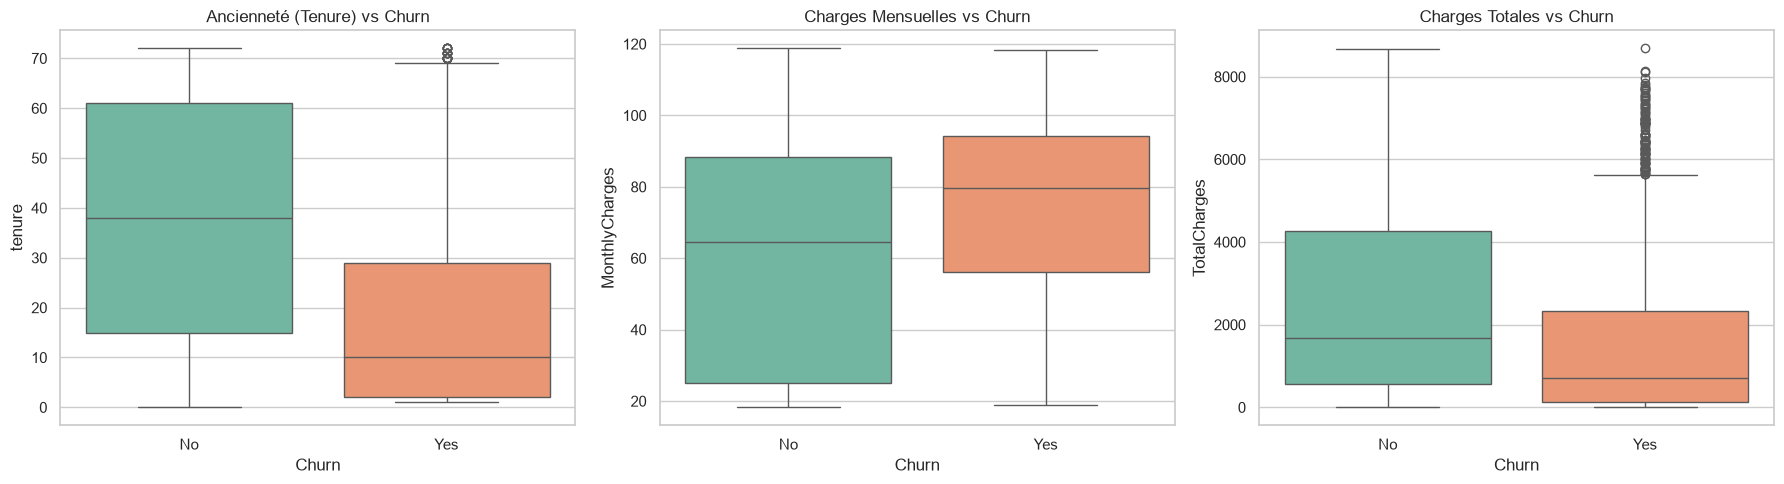

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=ax[0], palette='Set2')
ax[0].set_title('Ancienneté (Tenure) vs Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax[1], palette='Set2')
ax[1].set_title('Charges Mensuelles vs Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=ax[2], palette='Set2')
ax[2].set_title('Charges Totales vs Churn')

plt.tight_layout()
plt.show()

**Insights tirés des graphiques :**
- **Tenure :** Les clients qui partent (Yes) ont une ancienneté médiane beaucoup plus faible. Les nouveaux clients sont plus susceptibles de se désabonner.
- **MonthlyCharges :** Les clients qui partent ont tendance à avoir des factures mensuelles plus élevées.
- **TotalCharges :** Les charges totales sont plus basses pour ceux qui partent, ce qui s'explique logiquement par leur faible ancienneté (`tenure`).

### 3.2 Variables Catégorielles vs Churn

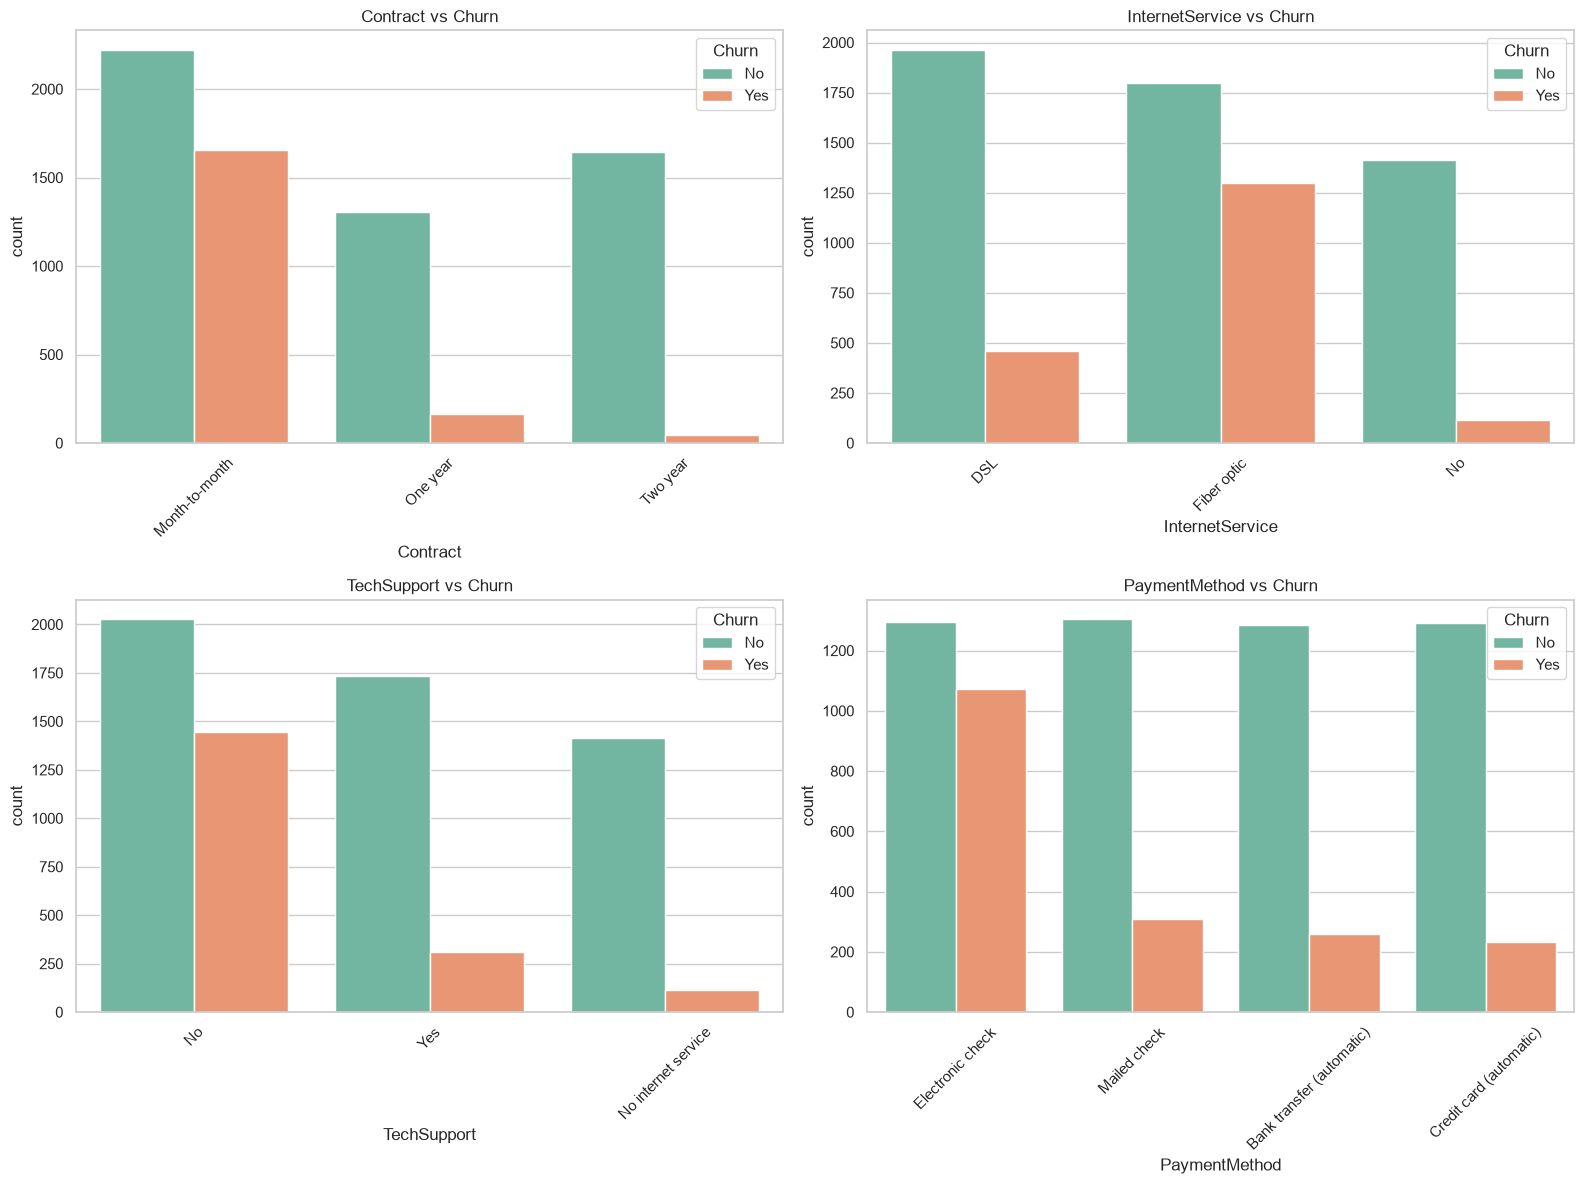

In [17]:
# Analysons quelques variables catégorielles clés
colonnes_cat = ['Contract', 'InternetService', 'TechSupport', 'PaymentMethod']

fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(colonnes_cat):
    row, col_idx = divmod(i, 2)
    sns.countplot(data=df, x=col, hue='Churn', ax=ax[row, col_idx], palette='Set2')
    ax[row, col_idx].set_title(f'{col} vs Churn')
    ax[row, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insights tirés des graphiques :**
- **Contract :** Les contrats au mois (Month-to-month) ont un taux de désabonnement extrêmement élevé par rapport aux contrats d'un an ou deux ans.
- **InternetService :** Les clients avec la fibre optique (Fiber optic) se désabonnent plus fréquemment que ceux en DSL.
- **TechSupport :** L'absence de support technique est corrélée à un taux de churn plus élevé.
- **PaymentMethod :** Le paiement par chèque électronique (Electronic check) est de loin la méthode la plus associée au churn.

## 4. Préparation (Sauvegarde)
Afin de ne pas refaire ce nettoyage pour les notebooks suivants (Clustering et Classification), nous allons sauvegarder notre dataframe propre.

In [18]:
# Sauvegarde du jeu de données nettoyé dans un nouveau fichier CSV
df.to_csv('../data/processed/telecom_churn_cleaned.csv', index=False)
print("Jeu de données nettoyé sauvegardé avec succès dans 'data/processed/telecom_churn_cleaned.csv'")

Jeu de données nettoyé sauvegardé avec succès dans 'data/processed/telecom_churn_cleaned.csv'
